In [16]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
import scipy.sparse as sp
from scipy.special import iv
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [17]:

# works out correlation matrix for returns in window size K ending at t - so up to time t
def correlation_matrix(returns, t, K, eps=0.0, active=None):
    t = pd.to_datetime(t)
    # 1. Slice the window
    window = returns.loc[t - pd.Timedelta(days=K*1.5): t]
    # 2. Filter for active and non-zero stocks
    if active is not None:
        window = window[active]
    if eps == 0.0:
        window = window.loc[:, (window.fillna(0.0) != 0.0).any(axis=0)]
    else:
        window = window.loc[:, (window.fillna(0.0).abs() > eps).any(axis=0)]

    active_cols = window.columns.tolist()
    # 3. Vectorized Math (NumPy is faster here)
    X = window.values # Shape: (Time, Stocks)
    X = np.nan_to_num(X) # Handle any remaining NaNs

    centered = X - np.mean(X, axis=0)
    # matrix multiplication: (Stocks, Time) @ (Time, Stocks) -> (Stocks, Stocks)
    cov = (centered.T @ centered) / (X.shape[0] - 1)

    std = np.sqrt(np.diag(cov))
    # Outer product of standard deviations with epsilon for stability
    denominator = np.outer(std, std) + 1e-9
    corr = cov / denominator

    return np.clip(corr, -1.0, 1.0), active_cols # Clip to ensure valid corr range

    # corr_matrix = window.corr().values
    # corr_matrix = np.nan_to_num(corr_matrix, nan=0.0, posinf=0.0, neginf=0.0)

    # return corr_matrix, active_cols

# function takes in historical returns for each t with window size K
# and computes initial node embeddings as H = US where Y = U S V^T is the SVD of the returns matrix Y

def compute_initial_node_embeddings(returns, t, K, eps=0.0, active=None):


    node_embeddings = {}
    t = pd.to_datetime(t)
    windowed_returns = returns.loc[t - pd.Timedelta(days=K*1.5): t].dropna(how='all')

    # Check if window is empty
    if windowed_returns.empty:
        return {}, []

    window = windowed_returns.dropna(axis=1, how="all")
    if active is not None:
        # Intersect active with available columns
        valid_active = [c for c in active if c in window.columns]
        if not valid_active:
            return {}, []
        window = window[valid_active]

    if window.shape[0] < 2 or window.shape[1] == 0: # Need at least some data
        return {}, []

    if eps == 0.0:
        window = window.loc[:, ~(window.fillna(0.0) == 0.0).all(axis=0)]
    else:
        window = window.loc[:, ~(window.fillna(0.0).abs() <= eps).all(axis=0)]

    active_cols = window.columns.tolist()
    if not active_cols:
        return {}, []
    data_to_svd = window.fillna(0.0).values
    data_to_svd = np.nan_to_num(data_to_svd, nan=0.0, posinf=0.0, neginf=0.0)
    U, S, Vt = np.linalg.svd(data_to_svd, full_matrices=False)
    V = Vt.T
    H = V @ np.diag(S)
    H = H[:, :10]

    # Handle case where SVD returns fewer than 10 components
    if H.shape[1] < 10:
        padding = np.zeros((H.shape[0], 10 - H.shape[1]))
        H = np.hstack([H, padding])

    scaler = StandardScaler()
    H = scaler.fit_transform(H)
    H = np.nan_to_num(H, nan=0.0)  # add this

    for i, stock in enumerate(active_cols):
        node_embeddings[stock] = H[i, :] # contains only one embedding per stock at time t, embedding shape (10,)

    # here - store the array directly in the list to match our structure
    for stock in node_embeddings:
        node_embeddings[stock] = np.array(node_embeddings[stock])

    return node_embeddings, active_cols

In [18]:
class SpectralBasisGenerator:

    def __init__(self, adj_matrix, s=1.0):
        self.adj = adj_matrix          # numpy (N, N) binary
        self.n_nodes = adj_matrix.shape[0]
        self.s = s
        self.L = self._compute_normalized_laplacian()

    def _compute_normalized_laplacian(self):
        A_sp = sp.csr_matrix(self.adj)
        row_sum = np.array(A_sp.sum(1))
        d_inv_sqrt = np.power(row_sum, -0.5).flatten()
        d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.
        D = sp.diags(d_inv_sqrt)
        A_norm = D @ A_sp @ D
        return sp.eye(self.n_nodes) - A_norm  # L = I - D^-0.5 A D^-0.5

    def get_eigen_pair(self):
        # eigh exploits symmetry of L and returns eigenvalues in ascending order.
        # Small eigenvalues -> smooth/low-frequency eigenvectors (global structure).
        # Large eigenvalues -> oscillatory/high-frequency eigenvectors (local anomalies).
        # Columns of eigvecs are therefore ordered from low to high frequency,
        # so the [:, :d] / [:, d:] split in SpGATCheby is now semantically correct.
        L_dense = self.L.toarray()
        eigvals, eigvecs = np.linalg.eigh(L_dense)
        return (torch.FloatTensor(eigvals),   # (N,)  ascending eigenvalues
                torch.FloatTensor(eigvecs))   # (N, N) columns ordered by ascending eigenvalue

    def get_eigenvectors(self):
        return self.get_eigen_pair()[1]

    def get_chebyshev_wavelets(self, order_M=3):  # kept for reference, not used
        L_tilde = self.L - sp.eye(self.n_nodes)
        c_i = [2 * np.exp(-self.s) * iv(i, self.s) for i in range(order_M + 1)]
        T_k = [sp.eye(self.n_nodes), L_tilde]
        Psi = 0.5 * c_i[0] * T_k[0] + c_i[1] * T_k[1]
        for k in range(2, order_M + 1):
            T_new = 2 * L_tilde @ T_k[-1] - T_k[-2]
            T_k.append(T_new)
            Psi += c_i[k] * T_new
        return torch.FloatTensor(Psi.toarray())  # (N, N)


In [19]:
class SpGATCheby(nn.Module):

    def __init__(self, in_features, out_features, d_proportion=0.15,
                 dropout=0.1):
        super().__init__()
        self.d_prop = d_proportion
        
        # Shared feature transformation theta (paper shares weights
        # across low and high branches to minimise parameters)
        self.theta = nn.Linear(in_features, out_features, bias=False)
        
        # THE two scalar attention weights from the paper
        # alpha_L weights low-frequency, alpha_H weights high-frequency
        # Softmax normalises them so they sum to 1 (eq 5 in paper)
        self.alpha_L = nn.Parameter(torch.tensor(1.0))
        self.alpha_H = nn.Parameter(torch.tensor(1.0))
        
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, basis_matrix, basis_matrix_inv): # x is (N, in_features), basis_matrix is (N, N) from generator func above , returns (N, out_features)

        N = basis_matrix.shape[0]
        d = max(1, int(N * self.d_prop))  # split boundary

        # Feature transform (shared theta, eq 7 in paper)
        X = self.dropout(self.theta(x))           # (N, out_features)

        # Split basis into low and high frequency columns
        # Smaller indices = low frequency (smooth, global)
        # Larger indices = high frequency (sharp, local anomalies)
        Psi_L = basis_matrix[:, :d]               # (N, d)
        Psi_H = basis_matrix[:, d:]               # (N, N-d)

        Psi_L_inv = basis_matrix_inv[:, :d].t()           # (d, N)
        Psi_H_inv = basis_matrix_inv[:, d:].t()           # (N-d, N)

        # Normalise the two scalar attention weights via softmax
        # so they are positive and comparable (eq 5 in paper)
        alpha = torch.softmax(
            torch.stack([self.alpha_L, self.alpha_H]), dim=0
        )                                         # (2,)
        a_L, a_H = alpha[0], alpha[1] # normalised 

        # Spectral convolution for each band (eq 7):
        # Psi * diag(alpha) * Psi^T * X
        # Since alpha is a scalar here (not per-component),
        # this simplifies to: alpha * (Psi @ Psi^T) @ X
        out_L = Psi_L @ ((Psi_L_inv @ X) * a_L) # (N, out_features)
        out_H = Psi_H @ ((Psi_H_inv @ X) * a_H) # (N, out_features)

        # out_L = a_L * (Psi_L @ Psi_L.t()) @ X    # (N, out_features)
        # out_H = a_H * (Psi_H @ Psi_H.t()) @ X    # (N, out_features)

        # MAX aggregation (paper finds this better than MEAN, Section 4.2)
        out = torch.max(out_L, out_H)             # (N, out_features) using max as paper says

        return self.activation(out)               # (N, out_features)

In [20]:
def compute_basis(corr_matrix_np, k_neighbors=10):
    # Build binary k-NN adjacency from absolute correlations, then return
    # the eigenvector matrix of the normalised Laplacian.
    # Shape returned: (N, N) FloatTensor, columns ordered low->high frequency.
    N = corr_matrix_np.shape[0]
    C = np.abs(corr_matrix_np.copy())
    np.fill_diagonal(C, 0.0)

    adj_binary = np.zeros((N, N), dtype=np.float32)
    k = min(k_neighbors, N - 1)
    for i in range(N):
        top_k = np.argpartition(C[i], -k)[-k:]
        adj_binary[i, top_k] = 1.0

    adj_binary = np.clip(adj_binary + adj_binary.T, 0, 1)  # make symmetric

    gen = SpectralBasisGenerator(adj_binary)
    eigenvals, eigenvecs = gen.get_eigen_pair()  # both (N,) and (N, N)

    # Build Psi_s = U * diag(e^{-lambda_i * s}) * U^T
    # eigenvals: (N,) ascending, eigenvecs: (N, N) columns ordered low->high
    g_s = torch.exp(-eigenvals * 1)              # (N,)  heat kernel values
    Psi_s = eigenvecs @ torch.diag(g_s) @ eigenvecs.t()  # (N, N)

    g_s_inv = torch.exp(eigenvals * 1)              # (N,) inverse heat kernel values
    Psi_s_inv = eigenvecs @ torch.diag(g_s_inv) @ eigenvecs.t()

    return Psi_s, Psi_s_inv  # (N, N) — replaces Chebyshev operator


In [21]:

class DiffusionConvLayer(nn.Module):

    #At each diffusion step s, compute:
    #Z_+ = sum_{s=0}^{S-1} θ_s,1 × (A_+_norm)^s × X
    #Z_- = sum_{s=0}^{S-1} θ_s,2 × (A_-_norm)^s × X
    #Output: [Z_+ || Z_-] concatenated

    def __init__(self, in_features, out_channels, num_diffusion_steps=1, bias=True, self_loop_weight=0.5):
    #in_features: Input feature dimension = d
    #out_channels: Number of output channels per network (Q)
    #num_diffusion_steps: Number of diffusion steps (S)
        super().__init__()

        self.in_features = in_features
        self.out_channels = out_channels
        self.num_diffusion_steps = num_diffusion_steps

        self.self_loop_weight = self_loop_weight

        # Learnable diffusion filters: one set for positive, one for negative
        # Shape: (S, d, Q) for each
        self.theta_pos = nn.Parameter(
            torch.Tensor(num_diffusion_steps, in_features, out_channels)
        )
        self.theta_neg = nn.Parameter(
            torch.Tensor(num_diffusion_steps, in_features, out_channels)
        )

        if bias:
            self.bias_pos = nn.Parameter(torch.Tensor(out_channels))
            self.bias_neg = nn.Parameter(torch.Tensor(out_channels))
        else:
            self.register_parameter('bias', None)

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.theta_pos)
        nn.init.xavier_uniform_(self.theta_neg)
        if self.bias_pos is not None:
            nn.init.zeros_(self.bias_pos)
        if self.bias_neg is not None:
            nn.init.zeros_(self.bias_neg)

    def forward(self, X_pos, X_neg, A_pos, A_neg):
        N = X_pos.shape[0] # X is N x d

        alpha = self.self_loop_weight
        # Normalize adjacency matrices for random walk
        # D^(-1) × A
        D_pos = A_pos.sum(dim=1, keepdim=True) + 1e-8  # (N, 1)
        D_neg = A_neg.sum(dim=1, keepdim=True) + 1e-8
        A_pos_norm = A_pos / D_pos  # (N, N)
        A_neg_norm = A_neg / D_neg

        I = torch.eye(N, device=X_pos.device)
        A_pos_norm = alpha * I + (1 - alpha) * A_pos_norm
        A_neg_norm = alpha * I + (1 - alpha) * A_neg_norm
        # Initialize outputs
        Z_pos = torch.zeros(N, self.out_channels, device=X_pos.device) # 0's
        Z_neg = torch.zeros(N, self.out_channels, device=X_neg.device)

        # Positive diffusion
        A_power = torch.eye(N, device=X_pos.device)  # A^0 = Identity matrix
        for s in range(self.num_diffusion_steps):
            # θ_s × (A^s × X) for each output channel where s is the diffusion step
            # A_power: (N, N), X: (N, d), theta_pos[s]: (d, Q)
            diffused = A_power @ X_pos  # (N, d)
            Z_pos += diffused @ self.theta_pos[s]  # (N, d) @ (d, Q) = (N, Q)
            A_power = A_power @ A_pos_norm  # Update A^s

        # Negative diffusion
        A_power = torch.eye(N, device=X_neg.device)
        for s in range(self.num_diffusion_steps):
            diffused = A_power @ X_neg
            Z_neg += diffused @ self.theta_neg[s]
            A_power = A_power @ A_neg_norm

        # Concatenate positive and negative outputs
        #Z = torch.cat([Z_pos, Z_neg], dim=1)  # (N, 2Q)

        if self.bias_pos is not None:
            Z_pos = Z_pos + self.bias_pos

        if self.bias_neg is not None:
            Z_neg = Z_neg + self.bias_neg

        return Z_pos, Z_neg # each is (N, Q)


In [22]:


class GraphConvGRUCell(nn.Module):



    def __init__(self, input_dim, hidden_dim, num_diffusion_steps=1):

        super().__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        # Diffusion layers for reset gate
        self.conv_r = DiffusionConvLayer(
            in_features=input_dim + hidden_dim,
            out_channels=hidden_dim,
            num_diffusion_steps=num_diffusion_steps
        )

        # Diffusion layers for update gate
        self.conv_u = DiffusionConvLayer(
            in_features=input_dim + hidden_dim,
            out_channels=hidden_dim,
            num_diffusion_steps=num_diffusion_steps
        )

        # Diffusion layers for candidate activation
        self.conv_c = DiffusionConvLayer(
            in_features=input_dim + hidden_dim,
            out_channels=hidden_dim,
            num_diffusion_steps=num_diffusion_steps
        )

    def forward(self, x_t_pos, x_t_neg, h_prev_pos, h_prev_neg, A_pos, A_neg):
        # Concatenate input and previous hidden state
        combined_pos = torch.cat([x_t_pos, h_prev_pos], dim=1)  # (N, input_dim + hidden_dim)
        combined_neg = torch.cat([x_t_neg, h_prev_neg], dim=1)  # (N, input_dim + hidden_dim)

        # Reset gate: r_t = sigmoid(DiffConv([x_t, h_{t-1}]))
        r_pos, r_neg = self.conv_r(combined_pos, combined_neg, A_pos, A_neg)  # (N, hidden_dim) each
        r_t_pos, r_t_neg = torch.sigmoid(r_pos), torch.sigmoid(r_neg)  # (N, hidden_dim) each

        # Update gate: u_t = sigmoid(DiffConv([x_t, h_{t-1}]))
        u_pos, u_neg = self.conv_u(combined_pos, combined_neg, A_pos, A_neg)
        u_t_pos, u_t_neg = torch.sigmoid(u_pos), torch.sigmoid(u_neg)  # (N, hidden_dim) each

        # Candidate: c_t = tanh(DiffConv([x_t, r_t * h_{t-1}]))
        #positive
        h_tilde_pos = r_t_pos * h_prev_pos  # Element-wise product
        h_tilde_neg = r_t_neg * h_prev_neg  # Element-wise product
        combined_c_pos = torch.cat([x_t_pos, h_tilde_pos], dim=1)
        combined_c_neg = torch.cat([x_t_neg, h_tilde_neg], dim=1)
        c_pos, c_neg = self.conv_c(combined_c_pos, combined_c_neg, A_pos, A_neg)
        c_t_pos, c_t_neg = torch.tanh(c_pos), torch.tanh(c_neg)  # (N, hidden_dim) each

        # Update hidden state: h_t = u_t * h_{t-1} + (1 - u_t) * c_t
        h_t_pos = u_t_pos * h_prev_pos + (1 - u_t_pos) * c_t_pos
        h_t_neg = u_t_neg * h_prev_neg + (1 - u_t_neg) * c_t_neg

        return h_t_pos, h_t_neg


In [23]:
class ReconstructionDecoder(nn.Module):

    def __init__(self, hidden_dim, feature_dim, use_structure_recon=False):

        super().__init__()

        self.use_structure_recon = use_structure_recon

        # Feature reconstruction: h_t → X_t (pred)
        self.feature_decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, feature_dim)
        )

        # Structure reconstruction is done via inner product: A_hat = sigmoid(h × h^T)
        # No parameters needed

    def forward(self, h_pos, h_neg, X_t, A_t_pos, A_t_neg):

        N = h_pos.shape[0]

        h_t = h_pos + h_neg
        # Reconstruct features
        X_hat = self.feature_decoder(h_t)  # (N, d)

        # Feature reconstruction error per node
        feature_error = torch.norm(X_t - X_hat, dim=1)  # (N,)

        # Reconstruct structure if requested
        if self.use_structure_recon and A_t_pos is not None and A_t_neg is not None:
            # Â = sigmoid(h × h^T)
            A_hat_pos = torch.sigmoid(h_pos @ h_pos.T)  # (N, N)
            A_hat_neg = torch.sigmoid(h_neg @ h_neg.T)  # (N, N)

            # Structure reconstruction error per node (row-wise)
            struct_err_pos = torch.norm(A_t_pos - A_hat_pos, dim=1)  # (N,)
            struct_err_neg = torch.norm(A_t_neg - A_hat_neg, dim=1)  # (N,)
            structure_error = 0.5 * (struct_err_pos + struct_err_neg)

            loss_struct_pos = torch.mean((A_t_pos - A_hat_pos) ** 2)
            loss_struct_neg = torch.mean((A_t_neg - A_hat_neg) ** 2)
            loss_struct = 0.5 * (loss_struct_pos + loss_struct_neg)

            # Combined error (alpha balances feature vs structure)
            alpha = 1
            combined_error = alpha * feature_error + (1 - alpha) * structure_error

            # Compute losses
            loss_feat = torch.mean(feature_error ** 2)
            total_loss = alpha * loss_feat + (1 - alpha) * loss_struct

        else:
            A_hat_pos = None
            A_hat_neg = None
            combined_error = feature_error
            total_loss = torch.mean(feature_error ** 2)

        # Normalize errors to [0, 1] range (bubble signals per node)
        #signals = (combined_error - combined_error.min()) / (combined_error.max() - combined_error.min() + 1e-8)
        signals = combined_error
        return X_hat, A_hat_pos, A_hat_neg, total_loss, signals


class BubbleDetectionModel(nn.Module):
    def __init__(self,
                 feature_dim,
                 embedding_dim,
                 hidden_dim,
                 spectral_out_dim=16,      # NEW: output dim of SpGAT
                 d_proportion=0.15,
                 num_diffusion_steps=1,
                 use_structure_recon=False,
                 dropout=0.1):

        super().__init__()

        self.feature_dim = feature_dim # d
        self.embedding_dim = embedding_dim # L - dim of PCA embeddings
        self.hidden_dim = hidden_dim # GRU hidden dim
        self.spectral_out_dim = spectral_out_dim # Q - output dim of SpGAT
        
        self.spgat = SpGATCheby(
            in_features=feature_dim,
            out_features=spectral_out_dim,
            d_proportion=d_proportion,
            dropout=dropout
        )

        # 3. GRU cell (we'll add embedding_dim because we concatenate H_t)
        self.gru = GraphConvGRUCell(
            input_dim=spectral_out_dim + embedding_dim,
            hidden_dim=hidden_dim,
            num_diffusion_steps=num_diffusion_steps
        )

        # 4. Decoder
        self.decoder = ReconstructionDecoder(
            hidden_dim=hidden_dim,
            feature_dim=feature_dim,
            use_structure_recon=use_structure_recon
        )

    def forward(self, X_t, H_t, basis_matrix, basis_matrix_inv, h_prev_pos=None, h_prev_neg=None, A_t_pos=None, A_t_neg=None, use_structure_recon=False):

        N = X_t.shape[0]

        # Initialise hidden state if None
        if h_prev_pos is None:
            h_prev_pos = torch.zeros(N, self.hidden_dim, device=X_t.device)
        if h_prev_neg is None:
            h_prev_neg = torch.zeros(N, self.hidden_dim, device=X_t.device)

        # Step 1: Compute attention weights with GAT
        # GAT expects (features, edge_index, corr_matrix)

        basis_matrix = basis_matrix.to(X_t.device)

        # Step 1: Spectral encoding (replaces GAT + SpatialEncoder)
        Z_spectral = self.spgat(X_t, basis_matrix, basis_matrix_inv)        # (N, spectral_out_dim) this is latent embedding using spGAT method
        # Same Z used for both pos/neg streams — SpGAT has no sign separation
        Z_t_pos = Z_spectral
        Z_t_neg = Z_spectral

        # Step 3: Concatenate with PCA embeddings (bypass connection)
        Z_t_full_pos = torch.cat([Z_t_pos, H_t], dim=1)  # (N, 2Q + L)
        Z_t_full_neg = torch.cat([Z_t_neg, H_t], dim=1)  # (N, 2Q + L)

        if A_t_pos is None:
            A_t_pos = torch.eye(N, device=X_t.device)
            A_t_neg = torch.zeros(N, N, device=X_t.device)
        # Step 4: GRU update
        h_t_pos, h_t_neg = self.gru(Z_t_full_pos, Z_t_full_neg, h_prev_pos, h_prev_neg, A_t_pos, A_t_neg)  # (N, hidden_dim)

        # Step 5: Decode and compute bubble signals
        X_hat, A_hat_pos, A_hat_neg, loss, bubble_signals = self.decoder(h_t_pos, h_t_neg, X_t, A_t_pos, A_t_neg)

        return h_t_pos, h_t_neg, bubble_signals, loss

    def attention_to_adjacency(self, attention_weights, edge_index, num_nodes):

        E = edge_index.shape[1] # (2, E -> 0 is src, 1 is trg)
        NH = attention_weights.shape[1] // 2 # (E, 2*NH, 1)

        # Average over attention heads
        att_pos = attention_weights[:, :NH, 0].mean(dim=1)  # (E,)
        att_neg = attention_weights[:, NH:, 0].mean(dim=1)  # (E,)

        # Create sparse adjacency matrices
        src = edge_index[0]
        trg = edge_index[1]

        A_pos = torch.zeros(num_nodes, num_nodes, device=attention_weights.device)
        A_neg = torch.zeros(num_nodes, num_nodes, device=attention_weights.device)

        A_pos[src, trg] = att_pos
        A_neg[src, trg] = att_neg

        # Make symmetric -> graph is undirected
        A_pos = (A_pos + A_pos.T) / 2
        A_neg = (A_neg + A_neg.T) / 2

        return A_pos, A_neg


In [24]:
#since some stocks may have missing data, only consider stocks that have at least min_obs observations in the lookback window
# some stocks only added to SPX after certain date, so we only consider stocks that have enough data in the lookback window

def get_active_stocks(returns, t, lookback_days, feature_dfs=None, min_obs=21, eps=0.0):
    t = pd.to_datetime(t)
    window = returns.loc[t - pd.Timedelta(days=lookback_days): t]

    # enough non-NaN observations
    counts = window.notna().sum(axis=0)
    ok_obs = counts >= min_obs

    # not constant zero in the window (treat as missing asset)
    if eps == 0.0:
        ok_nonzero = ~(window.fillna(0.0) == 0.0).all(axis=0)
    else:
        ok_nonzero = ~(window.fillna(0.0).abs() <= eps).all(axis=0)

    #active = window.columns[ok_obs & ok_nonzero].tolist()
    active = window.columns[ok_nonzero].tolist()

    if feature_dfs is not None:
        active_set = set(active)
        for df in feature_dfs:
            # only care if the stock exists as a column in the dataframe
            if not df.empty:
                # Find intersection between current active stocks and this dataframe's columns
                active_set = active_set.intersection(df.columns)

        active = list(active_set)

    return active

def train_step(model, optimizer, X_t, H_t, edge_index, corr_matrix, A_t_pos, A_t_neg, h_prev_pos, h_prev_neg):
    #Single training step
    model.train()
    optimizer.zero_grad()

    h_t_pos, h_t_neg, signals, loss, A_pos, A_neg = model(X_t, H_t, edge_index, corr_matrix, h_prev_pos, h_prev_neg, A_t_pos, A_t_neg)

    loss.backward()
    optimizer.step()

    return loss.item(), h_t_pos.detach(), h_t_neg.detach(), signals.detach()


def inference_step(model, X_t, H_t, edge_index, corr_matrix, h_prev_pos, h_prev_neg):
    model.eval()
    with torch.no_grad():
        h_t_pos, h_t_neg, signals, _, A_t_pos, A_t_neg = model(
            X_t, H_t, edge_index, corr_matrix, h_prev_pos=h_prev_pos, h_prev_neg=h_prev_neg, A_t_pos=None, A_t_neg=None
        )
    return h_t_pos, h_t_neg, signals, A_t_pos, A_t_neg

In [25]:
def create_adjacency_from_correlation(corr_matrix, threshold=0.0):

    N = corr_matrix.shape[0]
    C = np.array(corr_matrix, dtype=np.float32)
    k_neighbors = 10
    # Zero diagonal so a node doesn't select itself
    np.fill_diagonal(C, 0.0)

    # For each node, find top-k neighbors by absolute correlation
    A_pos = np.zeros((N, N), dtype=np.float32)
    A_neg = np.zeros((N, N), dtype=np.float32)

    for i in range(N):
        abs_corr = np.abs(C[i])
        # Get top-k indices (excluding self, already zeroed)
        k = min(k_neighbors, N - 1)
        top_k_idx = np.argpartition(abs_corr, -k)[-k:]

        for j in top_k_idx:
            if C[i, j] > 0:
                A_pos[i, j] = C[i, j]
            elif C[i, j] < 0:
                A_neg[i, j] = abs(C[i, j])

    # Make symmetric
    A_pos = (A_pos + A_pos.T) / 2
    A_neg = (A_neg + A_neg.T) / 2

    return torch.tensor(A_pos, dtype=torch.float32), torch.tensor(A_neg, dtype=torch.float32)
    # C = np.array(corr_matrix, dtype=np.float32)
    # A_pos = np.maximum(C, 0.0)
    # A_neg = np.maximum(-C, 0.0)
    # A_pos[A_pos < threshold] = 0 # min correlation to include edge
    # A_neg[A_neg < threshold] = 0
    # np.fill_diagonal(A_pos, 0) # self-loops
    # np.fill_diagonal(A_neg, 0) # self-loops
    # return torch.tensor(A_pos, dtype=torch.float32), torch.tensor(A_neg, dtype=torch.float32) # (N, N) is A

In [26]:
# functions for help

from torch.optim import Adam
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
import os
warnings.filterwarnings('ignore')
import traceback


def prepare_node_features(stocks, Z_DATA, t, norm_window=63): # 1 quarter
    """
    Normalise each feature per stock against its own rolling history (z-score),
    preserving signal relative to that stock's recent behaviour.
    """
    rows = []
    t = pd.to_datetime(t)

    for stock in stocks:

        # Simple lookup instead of rolling calculation
        feats = []
        for key in Z_DATA:
            df = Z_DATA[key]
            val = df.loc[t, stock] if stock in df.columns and t in df.index else 0.0
            feats.append(float(val))

        rows.append(feats)

    features = np.array(rows, dtype=np.float32)
    return torch.tensor(np.nan_to_num(features), dtype=torch.float32)

# def prepare_node_features(stocks, sectors, volatility, market_caps, pe_ratios, implied_vol, short_interest,
#                            beta, operating_margin, return_on_equity, rsi_momentum, turnover, t):

#     rows = []
#     t = pd.to_datetime(t)
#     if not stocks:
#         return torch.empty((0, 2), dtype=torch.float32)
#     for stock in stocks:
#         # Get factors for stock at time t (or default values if missing)
#         sector_id = sectors.loc[stock, 'sector_id'] if stock in sectors.index else 0
#         market_cap = market_caps.loc[t, stock] if t in market_caps.index and stock in market_caps.columns else 0.0
#         pe_ratio = pe_ratios.loc[t, stock] if t in pe_ratios.index and stock in pe_ratios.columns else 0.0
#         implied_volatility = implied_vol.loc[t, stock] if t in implied_vol.index and stock in implied_vol.columns else 0.0
#         short_int = short_interest.loc[t, stock] if t in short_interest.index and stock in short_interest.columns else 0.0
#         beta_val = beta.loc[t, stock] if t in beta.index and stock in beta.columns else 0.0
#         op_margin = operating_margin.loc[t, stock] if t in operating_margin.index and stock in operating_margin.columns else 0.0
#         roe = return_on_equity.loc[t, stock] if t in return_on_equity.index and stock in return_on_equity.columns else 0.0
#         rsi = rsi_momentum.loc[t, stock] if t in rsi_momentum.index and stock in rsi_momentum.columns else 0.0
#         turn = turnover.loc[t, stock] if t in turnover.index and stock in turnover.columns else 0.0

#         # Get volatility at time t (or nearest available)
#         if t in volatility.index and stock in volatility.columns:
#             vol = volatility.loc[t, stock]
#         else:
#             # Get closest date
#             available_dates = volatility.index[volatility.index <= t]
#             if len(available_dates) > 0:
#                 closest_date = available_dates[-1]
#                 vol = volatility.loc[closest_date, stock]
#             else:
#                 vol = 0.0  # Default if no data available
#         rows.append([sector_id, vol, market_cap, pe_ratio, implied_volatility, short_int, beta_val, op_margin, roe, rsi, turn])
#         # features is (N, 11)
#     features = np.array(rows, dtype=np.float32)
#     features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)#


#     if len(features) >0:
#         num_cols = features.shape[1]
#         for i in range(num_cols):  # Normalize each feature to [0, 1]
#             if features[:, i].max() > features[:, i].min():
#                 features[:, i] = (features[:, i] - features[:, i].min()) / (features[:, i].max() - features[:, i].min() + 1e-8)

#     non_zero_count = np.count_nonzero(features)
#     total_elements = features.size
#     zero_fraction = 1.0 - (non_zero_count / total_elements)

#     if zero_fraction > 0.9: # If more than 90% of data is zero
#         print(f"\n[WARNING] Time {t}: {zero_fraction*100:.1f}% of features are ZERO.")
#         print("Sample Row (first stock):", features[0])
#         # Check raw dataframe lookup for one stock to debug
#         test_stock = stocks[0]
#         print(f"Debug check for {test_stock} at {t}:")
#         if test_stock in pe_ratios.columns:
#             # Check if exact date exists
#             date_exists = t in pe_ratios.index
#             print(f"  - Date {t} in PE_ratios index? {date_exists}")
#             if not date_exists:
#                 # Show nearest dates
#                 print(f"  - PE_ratios nearby dates: {pe_ratios.index[pe_ratios.index.get_indexer([t], method='nearest')]}")

#     return torch.tensor(features, dtype=torch.float32)


def create_edge_index(corr_matrix, k_neighbors=10):
    """
    Creates an edge index where each node connects to its top-k most correlated peers.
    """
    N = corr_matrix.shape[0]
    if isinstance(corr_matrix, np.ndarray):
        corr = torch.tensor(corr_matrix, dtype=torch.float32)
    else:
        corr = corr_matrix.clone()

    #diagonal to -infinity so a node doesn't select itself
    mask_diag = torch.eye(N, dtype=torch.bool, device=corr.device)
    corr.masked_fill_(mask_diag, float('-inf'))

    # includes strong positive and strong negative correlations
    vals, indices = torch.topk(corr.abs(), k=min(k_neighbors, N-1), dim=1)

    # create Edge List

    src_list = torch.arange(N, device=corr.device).repeat_interleave(k_neighbors)
    trg_list = indices.flatten()

    edge_index = torch.stack([src_list, trg_list], dim=0)

    return edge_index

In [27]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, save_path='checkpoint.pt'):
        self.patience = patience
        self.min_delta = min_delta
        self.save_path = save_path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.save_path)

In [28]:

def train_model(model, optimizer, returns, volatility, Market_caps, PE_ratios, Implied_vol,
                 Beta, RSI_momentum, Turnover, Z_DATA,
                train_dates,stock2idx,patience=5,val_dates=None,embedding_cache=None, K=21, save_path='checkpoints'):

    device = next(model.parameters()).device
    #stocks = list(returns.columns)          # global universe order
    #stock2idx = {s: i for i, s in enumerate(stocks)}
    N_full = len(stock2idx)
    #stocks = list(returns.columns)
    #N = len(stocks)
    early_stopping = EarlyStopping(patience=patience, save_path=save_path)
    # Create edge index once (or you can recreate per timestamp)
    feature_dfs_list = [
    volatility, Market_caps, PE_ratios, Implied_vol,
    Beta, RSI_momentum, Turnover
    ]

    training_losses = []
    train_loss_history = []
    val_loss_history = []
    print(f"Training on {len(train_dates)} time steps...")

    for epoch in range(50):  # Multiple passes through training data
        epoch_losses = []
        #h_prev = None  # Reset hidden state each epoch
        h_prev_pos_full = torch.zeros(N_full, model.hidden_dim, dtype=torch.float32).to(device)  # Initialize hidden state
        h_prev_neg_full = torch.zeros(N_full, model.hidden_dim, dtype=torch.float32).to(device)  # Initialize hidden state
        for t in tqdm(train_dates, desc=f"Epoch {epoch+1}"):
            # Get active stocks at time t
            active = get_active_stocks(returns, t, lookback_days=int(K*1.5), feature_dfs=feature_dfs_list, min_obs=K)
            if not active: continue
            returns_t = returns[active]
            stocks_t = active
            # 1. Compute PCA embeddings from returns
            node_embeddings = embedding_cache.get(t)

            # Extract embeddings for all stocks
            H_list = []
            for stock in stocks_t:
                if stock in node_embeddings:
                    emb = node_embeddings[stock]
                    if len(emb.shape) > 1 and emb.shape[0] == 1:
                        H_list.append(emb[0])  # Take first embedding
                    else:
                        H_list.append(emb)
                    #H_list.append(node_embeddings[stock][0])  # Take first embedding
                else:
                    # Default embedding
                    H_list.append(np.zeros(10))  # Assuming L=10

            H_t = torch.tensor(np.array(H_list), dtype=torch.float32)

            # 2. Compute correlation matrix
            corr_matrix, _ = correlation_matrix(returns_t, t, K)
            basis_matrix, basis_matrix_inv = compute_basis(corr_matrix, k_neighbors=10)
            basis_matrix     = basis_matrix.to(device)
            basis_matrix_inv = basis_matrix_inv.to(device)

            # 3. Prepare node features [sector, volatility]
            X_t = prepare_node_features(stocks_t, Z_DATA, t)

            #if np.isnan(corr_matrix).any():
            #    print("NaNs in corr:", np.isnan(corr_matrix).sum())

            # 4. Create adjacency matrix for reconstruction (optional)
            A_t_pos, A_t_neg = create_adjacency_from_correlation(corr_matrix, threshold=0.0)
            A_t_pos = A_t_pos.to(device)
            A_t_neg = A_t_neg.to(device)

            active_idx = torch.tensor([stock2idx[s] for s in stocks_t], dtype=torch.long).to(device)
            h_prev_pos = h_prev_pos_full.index_select(0, active_idx)
            h_prev_neg = h_prev_neg_full.index_select(0, active_idx)
            # 5. Training step
            # loss, h_prev_pos,h_prev_neg, signals = train_step(
            #     model, optimizer, X_t, H_t, edge_index,
            #     corr_matrix_tensor, A_t_pos,A_t_neg, h_prev_pos, h_prev_neg
            # )
            model.train()
            optimizer.zero_grad()
            h_t_pos, h_t_neg, signals, loss = model(
                X_t, H_t, basis_matrix, basis_matrix_inv,
                h_prev_pos=h_prev_pos, h_prev_neg=h_prev_neg,
                A_t_pos=A_t_pos, A_t_neg=A_t_neg
            )
            if torch.isnan(loss) or torch.isinf(loss):
                print(f"Skipping NaN/Inf loss at {t}")
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # see Bug B
            optimizer.step()

            # Update full hidden states
            h_prev_pos_full[active_idx] = h_t_pos.detach()
            h_prev_neg_full[active_idx] = h_t_neg.detach()

            epoch_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            # Reset hidden states for validation sequence
            h_val_pos_full = torch.zeros(N_full, model.hidden_dim).to(device)
            h_val_neg_full = torch.zeros(N_full, model.hidden_dim).to(device)

            for t in val_dates:
                # 1. Get active stocks and features for time t
                active = get_active_stocks(returns, t, lookback_days=int(K*1.5),feature_dfs=feature_dfs_list, min_obs=K)
                if not active: continue

                returns_t = returns[active]
                stocks_t = active
                # 1. Compute PCA embeddings from returns
                node_embeddings = embedding_cache.get(t)

                # Extract embeddings for all stocks
                H_list = []
                for stock in stocks_t:
                    if stock in node_embeddings:
                        emb = node_embeddings[stock]
                        if len(emb.shape) > 1 and emb.shape[0] == 1:
                            H_list.append(emb[0])  # Take first embedding
                        else:
                            H_list.append(emb)
                        #H_list.append(node_embeddings[stock][0])  # Take first embedding
                    else:
                        # Default embedding
                        H_list.append(np.zeros(10))  # Assuming L=10

                H_t = torch.tensor(np.array(H_list), dtype=torch.float32)

                # 2. Compute correlation matrix
                corr_matrix, _ = correlation_matrix(returns_t, t, K)
                basis_matrix, basis_matrix_inv = compute_basis(corr_matrix, k_neighbors=10)
                basis_matrix     = basis_matrix.to(device)
                basis_matrix_inv = basis_matrix_inv.to(device)

                H_t = torch.tensor(np.array(H_list), dtype=torch.float32).to(device)
                corr_t = torch.tensor(corr_matrix, dtype=torch.float32).to(device)

                # 3. Prepare node features [sector, volatility]
                X_t = prepare_node_features(stocks_t, Z_DATA, t)

                #if np.isnan(corr_matrix).any():
                #    print("NaNs in corr:", np.isnan(corr_matrix).sum())

                # 4. Create adjacency matrix for reconstruction (optional)
                A_t_pos, A_t_neg = create_adjacency_from_correlation(corr_matrix, threshold=0.0)
                A_t_pos = A_t_pos.to(device)
                A_t_neg = A_t_neg.to(device)

                active_idx = torch.tensor([stock2idx[s] for s in stocks_t], dtype=torch.long).to(device)
                h_val_prev_pos = h_val_pos_full.index_select(0, active_idx)
                h_val_prev_neg = h_val_neg_full.index_select(0, active_idx)

                # 2. Forward pass only
                h_t_val_pos, h_t_val_neg, _, loss = model(X_t, H_t, basis_matrix, basis_matrix_inv,
                                            h_prev_pos=h_val_prev_pos, h_prev_neg=h_val_prev_neg)

                h_val_pos_full[active_idx] = h_t_val_pos.detach()
                h_val_neg_full[active_idx] = h_t_val_neg.detach()

                val_losses.append(loss.item())
        #print(f"Validation Loss: {val_losses}")
        avg_train_loss = np.mean(epoch_losses)
        avg_val_loss = np.mean(val_losses) if val_losses else float('inf')

        print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        train_loss_history.append(avg_train_loss)
        val_loss_history.append(avg_val_loss)

        # Check Early Stopping
        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping triggered")
            break

    model.load_state_dict(torch.load(save_path))
    return model, train_loss_history, val_loss_history


def test_model(model, returns, volatility, Market_caps, PE_ratios, Implied_vol, Beta,
               RSI_momentum, Turnover,Z_DATA, embedding_cache,test_dates, stock2idx, K=21):
    device = next(model.parameters()).device
    #stocks = list(returns.columns)
    N_full = len(stock2idx)

    h_prev_pos_full = torch.zeros(N_full, model.hidden_dim, device=device)
    h_prev_neg_full = torch.zeros(N_full, model.hidden_dim, device=device)

    feature_dfs_list = [
        volatility, Market_caps, PE_ratios, Implied_vol,
        Beta, RSI_momentum, Turnover
    ]
    # Storage for results
    all_signals = []
    valid_dates = []
    active_lists = []

    print(f"Testing on {len(test_dates)} time steps...")

    for t in tqdm(test_dates, desc="Testing"):
        try:
            # 1. Compute PCA embeddings
            active = get_active_stocks(returns, t, lookback_days=int(K*1.5), feature_dfs=feature_dfs_list, min_obs=K)
            #active_idx = torch.tensor([stock2idx[s] for s in active], dtype=torch.long)
            if not active:
                continue

            returns_t = returns[active]

            stocks_t    = active

            # Create edge index

            node_embeddings = embedding_cache.get(t)

            H_list = []
            for stock in stocks_t:
                if stock in node_embeddings.keys():
                    H_list.append(node_embeddings[stock])
                else:
                    H_list.append(np.zeros(10))

            H_t = torch.tensor(np.array(H_list), dtype=torch.float32)

            # 2. Correlation matrix
            corr_matrix, _ = correlation_matrix(returns_t, t, K)
            basis_matrix, basis_matrix_inv = compute_basis(corr_matrix, k_neighbors=10)
            basis_matrix     = basis_matrix.to(device)
            basis_matrix_inv = basis_matrix_inv.to(device)
            
            A_t_pos, A_t_neg = create_adjacency_from_correlation(corr_matrix)
            # 3. Node features
            X_t = prepare_node_features(stocks_t, Z_DATA, t)

            # 4. Inference
            # h_prev_pos, h_prev_neg, signals, A_pos, A_neg = inference_step(
            #     model, X_t, H_t, edge_index, corr_matrix_tensor, h_prev_pos, h_prev_neg
            # )
            active_idx = torch.tensor([stock2idx[s] for s in stocks_t], dtype=torch.long).to(device)
            h_prev_pos = h_prev_pos_full.index_select(0, active_idx)
            h_prev_neg = h_prev_neg_full.index_select(0, active_idx)

            with torch.no_grad():
                h_t_pos, h_t_neg, signals, _ = model(
                    X_t, H_t, basis_matrix, basis_matrix_inv,
                    h_prev_pos=h_prev_pos, h_prev_neg=h_prev_neg,
                    A_t_pos=A_t_pos, A_t_neg=A_t_neg, 
                    use_structure_recon=False
                )

            h_prev_pos_full[active_idx] = h_t_pos.detach()
            h_prev_neg_full[active_idx] = h_t_neg.detach()

            all_signals.append(signals.cpu().numpy())
            valid_dates.append(t)
            active_lists.append(stocks_t)

        except Exception as e:
            # FIX: Print the ACTUAL error to debug
            print(f"\n!!! Error at {t} !!!")
            traceback.print_exc()
            continue
        # except Exception as e:
        #     raise RuntimeError(f"Test failed at time {t}") from e

    # # Create results DataFrame
    # signals_array = np.array(all_signals)  # (T, N)
    # results = pd.DataFrame(
    #     signals_array,
    #     index=valid_dates,
    #     columns=stocks
    # )
    results = {d: (active_lists[i], all_signals[i]) for i, d in enumerate(valid_dates)}
    return results



In [29]:
# # After loading data, before training loop:
# print("\n[1/6] Loading data...")
# device = torch.device("cpu")

# # Load prices
# prices = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
# prices.dropna(how='all', inplace=True)
# prices = prices.ffill().bfill()
# prices.columns = prices.columns.droplevel(1)

# all_stocks = prices.columns.tolist()
# stock2idx = {s: i for i, s in enumerate(all_stocks)}
# idx2stock = {i: s for s, i in stock2idx.items()}
# N_full = len(all_stocks)

# # Load sectors
# sectors = pd.read_excel('SPX_sectors_data.xlsx', sheet_name='Sectors',
#                         header=0, index_col=0)
# sectors['sector_id'] = sectors['Sector'].astype('category').cat.codes


# tickers = prices.columns.get_level_values(0).unique().tolist()
# node_map = {ticker: i for i, ticker in enumerate(tickers)}

# # Split data: Train 2007-2009, Test 2019-2021
# train_prices = prices.loc['2012-01-01':'2016-12-31']
# test_prices = prices.loc['2019-07-01':'2024-12-31']
# val_prices = prices.loc["2017-01-01":"2019-06-30"]

# returns = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
# returns.columns = returns.columns.get_level_values(0)
# returns.dropna(how='all', inplace=True)
# returns = returns.pct_change().dropna(how='all')
# #returns = returns.ffill().bfill()
# # Compute returns
# # train_returns = train_prices.pct_change().dropna(how='all')
# # test_returns = test_prices.pct_change().dropna(how='all')
# train_returns = returns.loc['2012-01-01':'2016-12-31']
# train_returns = train_returns.ffill().bfill()
# test_returns = returns.loc['2019-07-01':'2024-12-31']
# test_returns = test_returns.ffill().bfill()
# val_returns = returns.loc["2017-01-01":"2019-06-30"]
# val_dates = val_returns.index
# all_dates = sorted(set(train_returns.index) | set(test_returns.index) | set(val_returns.index))
# # Compute volatility
# train_volatility = train_returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)
# test_volatility = test_returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)
# volatility = pd.concat([train_volatility, test_volatility]).sort_index()

# # Helper to load and fix dates
# def load_and_fix_index(filename):
#     df = pd.read_csv(filename, index_col=0)
#     df.index = pd.to_datetime(df.index, format='%m/%d/%Y') # Fix date format
#     df.dropna(how='all', inplace=True)
#     df = df.ffill().bfill()
#     return df

# # Load Constituent Factors (Tables where Cols = Tickers, Rows = Dates)
# Market_caps = load_and_fix_index('Data/SPX_Constituents_market_cap_2006_2025(in).csv')

# PE_ratios = load_and_fix_index('Data/SPX_Constituents_Calculated_PE_2006_2025(in).csv')

# Implied_vol = load_and_fix_index('Data/SPX_Constituents_Implied_vol_2006_2025(in).csv')

# Beta = load_and_fix_index('Data/SPX_Constituents_Beta_2006_2025(in).csv')
# #Operating_margin = load_and_fix_index('Data/SPX_Constituents_Op_Margin_2006_2025(in).csv')
# #Return_on_equity = load_and_fix_index('Data/SPX_Constituents_Ret_On_Equity_2006_2025(in).csv')
# RSI_momentum = load_and_fix_index('Data/SPX_Constituents_RSI_momentum_2006_2025(in).csv')
# #Short_interest = load_and_fix_index('Data/SPX_Constituents_Short_Interest_Pct_2006_2025(in).csv')
# Turnover = load_and_fix_index('Data/SPX_Constituents_Turnover_30D_2006_2025(in).csv')


# print(f"Training period: {train_returns.index[0]} to {train_returns.index[-1]}")
# print(f"Testing period: {test_returns.index[0]} to {test_returns.index[-1]}")
# print(f"Number of stocks: {len(train_returns.columns)}")

# # prep trainig and testing dates
# print("\n[2/6] Preparing training dates...")

# K = 21  # Window size
# min_date = train_returns.index[0] + pd.Timedelta(days=K*2)
# train_dates = train_returns.loc[min_date:].index

# test_min_date = test_returns.index[0] + pd.Timedelta(days=K*2)
# test_dates = test_returns.loc[test_min_date:].index

# print(f"Training time steps: {len(train_dates)}")
# print(f"Testing time steps: {len(test_dates)}")

# print('Precomputing Z scores for all features...')

# def precompute_zscores(df, window=63):
#     """Calculates rolling z-scores for an entire dataframe at once."""
#     rolling_mean = df.rolling(window=window, min_periods=5).mean()
#     rolling_std = df.rolling(window=window, min_periods=5).std()
#     # Avoid division by zero with 1e-8
#     z_scores = (df - rolling_mean) / (rolling_std + 1e-8)
#     # Clip outliers to keep gradients stable and fill NaNs
#     return z_scores.clip(-5.0, 5.0).fillna(0.0)

# # Precompute z-scores for all feature dataframes
# Z_DATA = {
#     'volatility':       precompute_zscores(volatility), # use your vol_window here
#     'market_caps':      precompute_zscores(Market_caps),
#     'pe_ratios':        precompute_zscores(PE_ratios),
#     'implied_vol':      precompute_zscores(Implied_vol),
#     #'short_interest':   precompute_zscores(Short_interest),
#     'beta':             precompute_zscores(Beta),
#     #'op_margin':        precompute_zscores(Operating_margin),
#     #'roe':              precompute_zscores(Return_on_equity),
#     'rsi':              precompute_zscores(RSI_momentum),
#     'turnover':         precompute_zscores(Turnover)
# }
# # initialize model
# print("\n[3/6] Initializing model...")

# # Model hyperparameters
# N = len(train_returns.columns)  # Number of stocks
# feature_dim = 7  # [volatility, market caps, PE, Implied_vol, ShortInterestPct, Beta, RSI, Turnover] TODO: try adding more features
# embedding_dim = 10  # PCA embedding dimension (L)


# final_test_results = []

# embedding_cache = {}
# print(f"Pre-computing embeddings for {len(all_dates)} dates...")
# for t in tqdm(all_dates):
#     # We reuse your existing function logic
#     node_embeddings, _ = compute_initial_node_embeddings(returns, t, K)
#     embedding_cache[t] = node_embeddings

# seed = 0
# torch.manual_seed(seed)
# np.random.seed(seed)

# test_t = train_dates[10]

# feature_dfs_list=[volatility, Market_caps, PE_ratios, Implied_vol, Beta, RSI_momentum, Turnover]
# active = get_active_stocks(returns, test_t, lookback_days=int(K*1.5),
#                            feature_dfs=feature_dfs_list, min_obs=K)
# returns_t = returns[active]
# node_embeddings = embedding_cache.get(test_t)
# H_list = [node_embeddings[s] for s in active]
# H_t = torch.tensor(np.array(H_list), dtype=torch.float32)
# corr_matrix, _ = correlation_matrix(returns_t, test_t, K)
# basis_matrix = compute_basis(corr_matrix, k_neighbors=10)
# X_t = prepare_node_features(active, Z_DATA, test_t)
# A_t_pos, A_t_neg = create_adjacency_from_correlation(corr_matrix)
# model = BubbleDetectionModel(
#     feature_dim=feature_dim,
#     embedding_dim=embedding_dim,
#     hidden_dim=32,
#     spectral_out_dim=16,
#     d_proportion=0.15,
#     num_diffusion_steps=2,
#     use_structure_recon=True,
#     dropout=0.1
# )
# h_t_pos, h_t_neg, signals, loss = model(X_t, H_t, basis_matrix,
#                                          A_t_pos=A_t_pos, A_t_neg=A_t_neg)
# print(f"Signals shape: {signals.shape}, loss: {loss.item():.4f}")
# print(f"Alpha_L: {torch.softmax(torch.stack([model.spgat.alpha_L, model.spgat.alpha_H]), dim=0)[0].item():.3f}")


[1/6] Loading data...
Training period: 2012-01-03 00:00:00 to 2016-12-30 00:00:00
Testing period: 2019-07-01 00:00:00 to 2024-12-31 00:00:00
Number of stocks: 503

[2/6] Preparing training dates...
Training time steps: 1229
Testing time steps: 1357
Precomputing Z scores for all features...

[3/6] Initializing model...
Pre-computing embeddings for 3270 dates...


100%|██████████| 3270/3270 [04:21<00:00, 12.52it/s]



=== Running with seed 0 ===
Total parameters: 23,865

[4/6] Training model...
Training on 1229 time steps...


Epoch 1: 100%|██████████| 1229/1229 [06:24<00:00,  3.20it/s]


Epoch 1: Train Loss: 2.4362 | Val Loss: 0.5691


...

Epoch 10: Train Loss: 0.4126 | Val Loss: 0.2599


Epoch 11: 100%|██████████| 1229/1229 [05:57<00:00,  3.44it/s]


Epoch 11: Train Loss: 0.4064 | Val Loss: 0.2786


Epoch 12: 100%|██████████| 1229/1229 [04:14<00:00,  4.83it/s]


Epoch 12: Train Loss: 0.3996 | Val Loss: 0.2594
Early stopping triggered


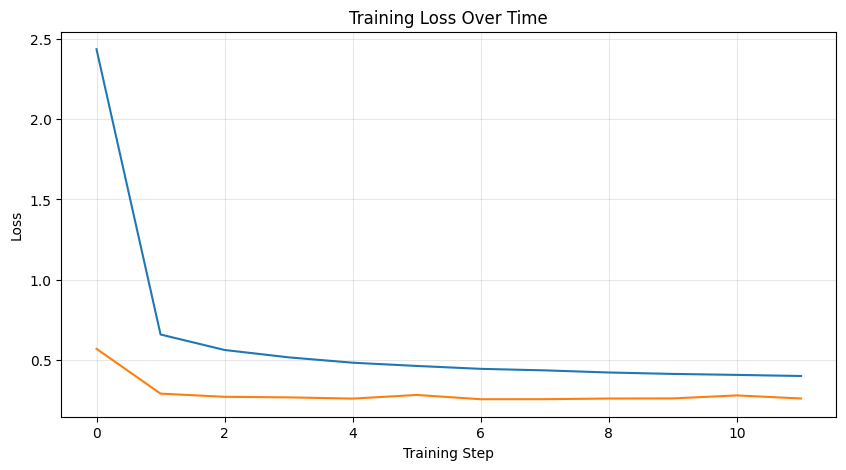


[5/6] Testing model...
Testing on 1357 time steps...


Testing: 100%|██████████| 1357/1357 [10:10<00:00,  2.22it/s]



=== Running with seed 2 ===
Total parameters: 23,865

[4/6] Training model...
Training on 1229 time steps...


Epoch 1: 100%|██████████| 1229/1229 [07:45<00:00,  2.64it/s]


Epoch 1: Train Loss: 2.4362 | Val Loss: 0.5691


...

Epoch 10: Train Loss: 0.4126 | Val Loss: 0.2599


Epoch 11: 100%|██████████| 1229/1229 [07:12<00:00,  2.84it/s]


Epoch 11: Train Loss: 0.4064 | Val Loss: 0.2786


Epoch 12: 100%|██████████| 1229/1229 [06:45<00:00,  3.03it/s]


Epoch 12: Train Loss: 0.3996 | Val Loss: 0.2594
Early stopping triggered


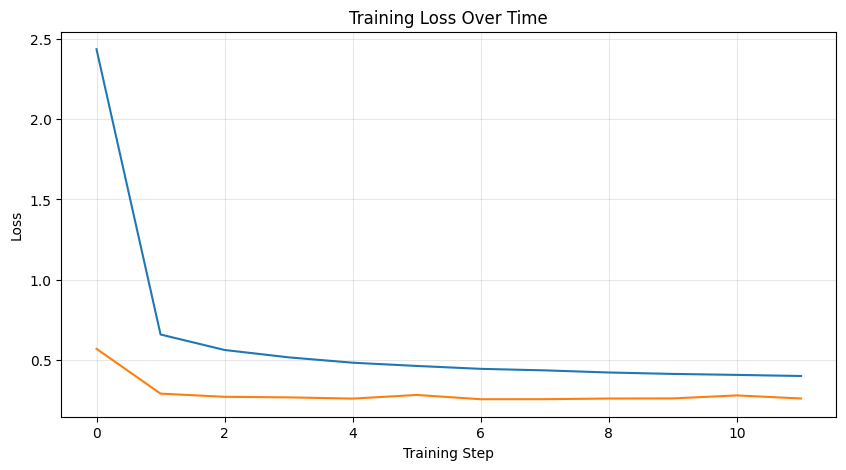


[5/6] Testing model...
Testing on 1357 time steps...


Testing: 100%|██████████| 1357/1357 [09:24<00:00,  2.40it/s]



=== Running with seed 4 ===
Total parameters: 23,865

[4/6] Training model...
Training on 1229 time steps...


Epoch 1: 100%|██████████| 1229/1229 [07:07<00:00,  2.87it/s]


Epoch 1: Train Loss: 2.4362 | Val Loss: 0.5691


...

Epoch 10: Train Loss: 0.4126 | Val Loss: 0.2599


Epoch 11: 100%|██████████| 1229/1229 [08:46<00:00,  2.34it/s]


Epoch 11: Train Loss: 0.4064 | Val Loss: 0.2786


Epoch 12: 100%|██████████| 1229/1229 [07:52<00:00,  2.60it/s]


Epoch 12: Train Loss: 0.3996 | Val Loss: 0.2594
Early stopping triggered


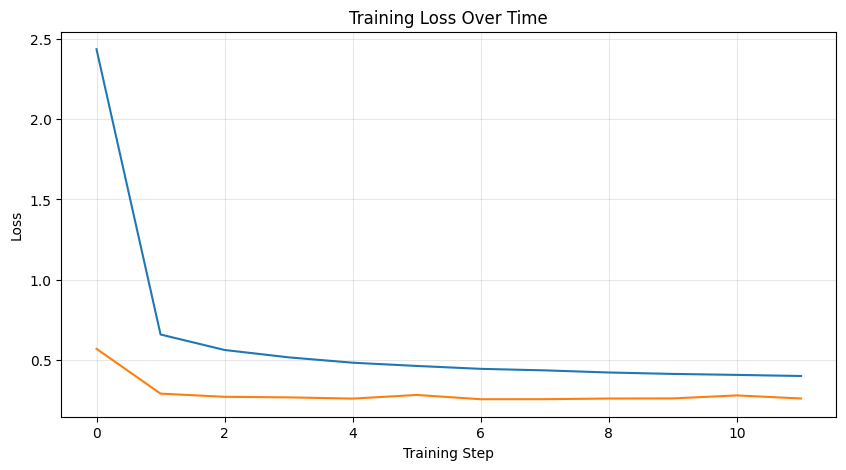


[5/6] Testing model...
Testing on 1357 time steps...


Testing: 100%|██████████| 1357/1357 [12:17<00:00,  1.84it/s]



=== Running with seed 6 ===
Total parameters: 23,865

[4/6] Training model...
Training on 1229 time steps...


Epoch 1: 100%|██████████| 1229/1229 [09:22<00:00,  2.19it/s]


Epoch 1: Train Loss: 2.4362 | Val Loss: 0.5691


...

Epoch 10: Train Loss: 0.4126 | Val Loss: 0.2599


Epoch 11: 100%|██████████| 1229/1229 [04:33<00:00,  4.49it/s]


Epoch 11: Train Loss: 0.4064 | Val Loss: 0.2786


Epoch 12: 100%|██████████| 1229/1229 [04:32<00:00,  4.50it/s]


Epoch 12: Train Loss: 0.3996 | Val Loss: 0.2594
Early stopping triggered


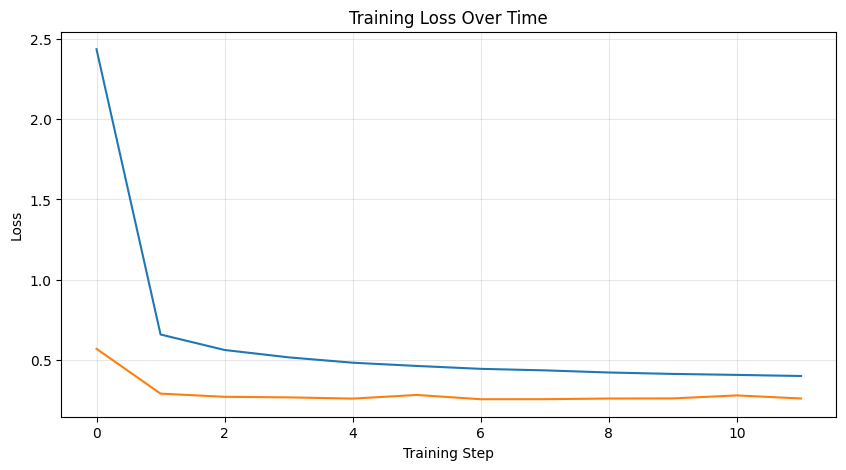


[5/6] Testing model...
Testing on 1357 time steps...


Testing: 100%|██████████| 1357/1357 [05:51<00:00,  3.86it/s]


In [30]:

def main():

    # prep data
    print("\n[1/6] Loading data...")
    device = torch.device("cpu")

    # Load prices
    prices = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
    prices.dropna(how='all', inplace=True)
    prices = prices.ffill().bfill()
    prices.columns = prices.columns.droplevel(1)

    all_stocks = prices.columns.tolist()
    stock2idx = {s: i for i, s in enumerate(all_stocks)}
    idx2stock = {i: s for s, i in stock2idx.items()}
    N_full = len(all_stocks)

    # Load sectors
    sectors = pd.read_excel('SPX_sectors_data.xlsx', sheet_name='Sectors',
                            header=0, index_col=0)
    sectors['sector_id'] = sectors['Sector'].astype('category').cat.codes


    tickers = prices.columns.get_level_values(0).unique().tolist()
    node_map = {ticker: i for i, ticker in enumerate(tickers)}

    # Split data: Train 2007-2009, Test 2019-2021
    train_prices = prices.loc['2012-01-01':'2016-12-31']
    test_prices = prices.loc['2019-07-01':'2024-12-31']
    val_prices = prices.loc["2017-01-01":"2019-06-30"]

    returns = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
    returns.columns = returns.columns.get_level_values(0)
    returns.dropna(how='all', inplace=True)
    returns = returns.pct_change().dropna(how='all')
    #returns = returns.ffill().bfill()
    # Compute returns
    # train_returns = train_prices.pct_change().dropna(how='all')
    # test_returns = test_prices.pct_change().dropna(how='all')
    train_returns = returns.loc['2012-01-01':'2016-12-31']
    train_returns = train_returns.ffill().bfill()
    test_returns = returns.loc['2019-07-01':'2024-12-31']
    test_returns = test_returns.ffill().bfill()
    val_returns = returns.loc["2017-01-01":"2019-06-30"]
    val_dates = val_returns.index
    all_dates = sorted(set(train_returns.index) | set(test_returns.index) | set(val_returns.index))
    # Compute volatility
    train_volatility = train_returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)
    test_volatility = test_returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)
    volatility = pd.concat([train_volatility, test_volatility]).sort_index()

    # Helper to load and fix dates
    def load_and_fix_index(filename):
        df = pd.read_csv(filename, index_col=0)
        df.index = pd.to_datetime(df.index, format='%m/%d/%Y') # Fix date format
        df.dropna(how='all', inplace=True)
        df = df.ffill().bfill()
        return df

    # Load Constituent Factors (Tables where Cols = Tickers, Rows = Dates)
    Market_caps = load_and_fix_index('Data/SPX_Constituents_market_cap_2006_2025(in).csv')

    PE_ratios = load_and_fix_index('Data/SPX_Constituents_Calculated_PE_2006_2025(in).csv')

    Implied_vol = load_and_fix_index('Data/SPX_Constituents_Implied_vol_2006_2025(in).csv')

    Beta = load_and_fix_index('Data/SPX_Constituents_Beta_2006_2025(in).csv')
    #Operating_margin = load_and_fix_index('Data/SPX_Constituents_Op_Margin_2006_2025(in).csv')
    #Return_on_equity = load_and_fix_index('Data/SPX_Constituents_Ret_On_Equity_2006_2025(in).csv')
    RSI_momentum = load_and_fix_index('Data/SPX_Constituents_RSI_momentum_2006_2025(in).csv')
    #Short_interest = load_and_fix_index('Data/SPX_Constituents_Short_Interest_Pct_2006_2025(in).csv')
    Turnover = load_and_fix_index('Data/SPX_Constituents_Turnover_30D_2006_2025(in).csv')


    print(f"Training period: {train_returns.index[0]} to {train_returns.index[-1]}")
    print(f"Testing period: {test_returns.index[0]} to {test_returns.index[-1]}")
    print(f"Number of stocks: {len(train_returns.columns)}")

    # prep trainig and testing dates
    print("\n[2/6] Preparing training dates...")

    K = 21  # Window size
    min_date = train_returns.index[0] + pd.Timedelta(days=K*2)
    train_dates = train_returns.loc[min_date:].index

    test_min_date = test_returns.index[0] + pd.Timedelta(days=K*2)
    test_dates = test_returns.loc[test_min_date:].index

    print(f"Training time steps: {len(train_dates)}")
    print(f"Testing time steps: {len(test_dates)}")

    print('Precomputing Z scores for all features...')

    def precompute_zscores(df, window=63):
        """Calculates rolling z-scores for an entire dataframe at once."""
        rolling_mean = df.rolling(window=window, min_periods=5).mean()
        rolling_std = df.rolling(window=window, min_periods=5).std()
        # Avoid division by zero with 1e-8
        z_scores = (df - rolling_mean) / (rolling_std + 1e-8)
        # Clip outliers to keep gradients stable and fill NaNs
        return z_scores.clip(-5.0, 5.0).fillna(0.0)

    # Precompute z-scores for all feature dataframes
    Z_DATA = {
        'volatility':       precompute_zscores(volatility), # use your vol_window here
        'market_caps':      precompute_zscores(Market_caps),
        'pe_ratios':        precompute_zscores(PE_ratios),
        'implied_vol':      precompute_zscores(Implied_vol),
        #'short_interest':   precompute_zscores(Short_interest),
        'beta':             precompute_zscores(Beta),
        #'op_margin':        precompute_zscores(Operating_margin),
        #'roe':              precompute_zscores(Return_on_equity),
        'rsi':              precompute_zscores(RSI_momentum),
        'turnover':         precompute_zscores(Turnover)
    }
    # initialize model
    print("\n[3/6] Initializing model...")

    # Model hyperparameters
    N = len(train_returns.columns)  # Number of stocks
    feature_dim = 7  # [volatility, market caps, PE, Implied_vol, ShortInterestPct, Beta, RSI, Turnover] TODO: try adding more features
    embedding_dim = 10  # PCA embedding dimension (L)


    final_test_results = []

    embedding_cache = {}
    print(f"Pre-computing embeddings for {len(all_dates)} dates...")
    for t in tqdm(all_dates):
        # We reuse your existing function logic
        node_embeddings, _ = compute_initial_node_embeddings(returns, t, K)
        embedding_cache[t] = node_embeddings

    # seeds = np.random.randint(0, 10, size=3)  # Run with 3 different random seeds for robustness
    seeds = [0, 2, 4, 6]
    #d_props = [0.15, 0.2, 0.25, 0.35, 0.4, 0.5]
    for seed in seeds:
        torch.manual_seed(seed)
        np.random.seed(seed)
        print(f'\n=== Running with seed {seed} ===')
        torch.manual_seed(2)
        np.random.seed(2)
        model = BubbleDetectionModel(
            feature_dim=feature_dim,
            embedding_dim=embedding_dim,
            hidden_dim=32,  # GRU hidden dimension
            spectral_out_dim=16,
            d_proportion=0.2,
            num_diffusion_steps=2,
            use_structure_recon=True,
            dropout=0.1
        )

        optimizer = Adam(model.parameters(), lr=0.001, weight_decay=1e-05)

        total_params = sum(p.numel() for p in model.parameters())
        print(f"Total parameters: {total_params:,}")

        # training
        print("\n[4/6] Training model...")

        # Create output directory
        os.makedirs('outputs', exist_ok=True)

        # model, training_losses, val_losses = train_model(
        #     model, optimizer, returns, sectors, train_volatility, Market_caps, PE_ratios, Implied_vol,
        #     Short_interest, Beta, Operating_margin, Return_on_equity, RSI_momentum, Turnover, Z_DATA,
        #     train_dates, stock2idx, patience=5, val_dates=val_dates, embedding_cache=embedding_cache, K=K, save_path='outputs/bubble_model.pt'
        # )
        model, training_losses, val_losses = train_model(
            model, optimizer, returns, train_volatility, Market_caps, PE_ratios, Implied_vol,
            Beta, RSI_momentum, Turnover, Z_DATA,
            train_dates, stock2idx, patience=5, val_dates=val_dates, embedding_cache=embedding_cache, K=K, save_path='outputs/bubble_model.pt'
        )


        # Plot training loss
        plt.figure(figsize=(10, 5))
        plt.plot(training_losses)
        plt.plot(val_losses)
        plt.xlabel('Training Step')
        plt.ylabel('Loss')
        plt.title('Training Loss Over Time')
        plt.grid(alpha=0.3)
        plt.savefig('outputs/training_loss.png', dpi=300, bbox_inches='tight')
        plt.show()

        # testing
        print("\n[5/6] Testing model...")

        #test_results = test_model(model, test_returns, sectors, test_volatility, Market_caps, PE_ratios, Implied_vol, Short_interest, Beta,
        #            Operating_margin, Return_on_equity, RSI_momentum, Turnover, Z_DATA, embedding_cache, test_dates, stock2idx, K=21) # d:(active_stocks, signals_array)
        test_results = test_model(model, test_returns, test_volatility, Market_caps, PE_ratios, Implied_vol, Beta,
                    RSI_momentum, Turnover, Z_DATA, embedding_cache, test_dates, stock2idx, K=21)

        final_test_results.append(test_results)

    final_test_results_dict = {} # date: (stocks, avg_signals)
    for test_result in final_test_results:
        for date, (stocks, signals) in test_result.items():
            if date not in final_test_results_dict:
                final_test_results_dict[date] = (stocks, [signals])
            else:
                final_test_results_dict[date][1].append(signals)
    # Now average signals for each date and stock
    for date, (stocks, signals_list) in final_test_results_dict.items():
        avg_signals = np.mean(signals_list, axis=0)  # Average across seeds
        final_test_results_dict[date] = (stocks, avg_signals)
    # Save results
    pd.to_pickle(test_results, f"outputs/test_results_test_30Apr_spectral_0_2_trial.pkl")
    pd.to_pickle(test_prices, f"outputs/test_prices_test_30Apr_spectral_0_2_trial.pkl")
    return test_results, test_prices

if __name__ == "__main__":
    test_results, test_prices = main()

[5] Visualizing Average Anomaly Signal (Regression Baseline)...


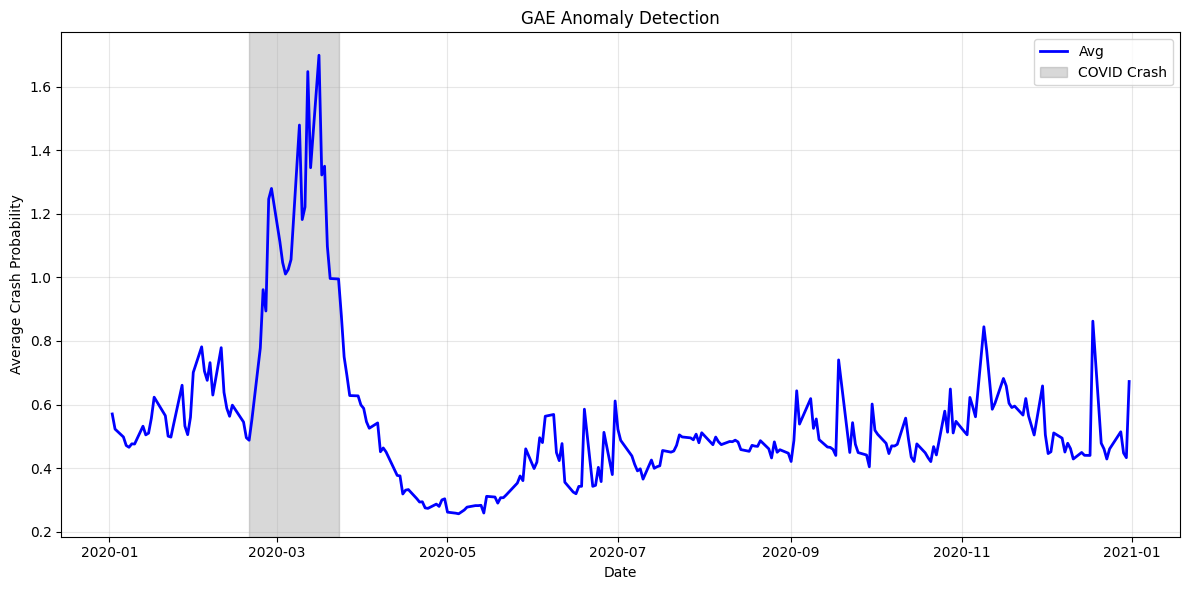

In [31]:
print("[5] Visualizing Average Anomaly Signal (Regression Baseline)...")

# 1. Convert the dictionary results into a pandas Series of average scores
# reg_results structure: {date: (active_stocks_list, probabilities_array)}
date_map = {}
test_results = pd.read_pickle('outputs/test_results_test_30Apr_spectral_0_2_trial.pkl')

for date, (stocks, probs) in test_results.items():
    # We take the mean of the probabilities for that specific day
    date_map[date] = np.mean(probs)

# Create a Series sorted by date
avg_signals = pd.Series(date_map).sort_index()

# 2. Filter for 2020
try:
    # Slice the series for the year 2020
    avg_signals_2020 = avg_signals.loc['2020-01-01':'2021-01-01']
except KeyError:
    print("Warning: Date range not found in data.")
    avg_signals_2020 = pd.Series()

# 3. Plot
if not avg_signals_2020.empty:
    plt.figure(figsize=(12, 6))

    # Plot directly using the index (dates) and values
    plt.plot(avg_signals_2020.index, avg_signals_2020.values, color='blue', linewidth=2, label='Avg')
    # Highlight COVID Crash
    plt.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-03-23'),
                color='grey', alpha=0.3, label='COVID Crash')

    plt.title("GAE Anomaly Detection")
    plt.ylabel("Average Crash Probability")
    plt.xlabel("Date")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No data found for 2020.")

In [32]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
import torch


def evaluate_once(
        test_results,
        prices,
        forward_window,
        crash_threshold
):

    y_true = []
    y_scores = []

    sorted_dates = sorted(test_results.keys())

    valid_dates = [
        d for d in sorted_dates
        if d <= prices.index[-1] - pd.Timedelta(days=forward_window)
    ]

    for t in valid_dates:

        stocks, signals = test_results[t]

        if isinstance(signals, torch.Tensor):
            signals = signals.cpu().numpy()

        signals = signals.flatten()

        available = [s for s in stocks if s in prices.columns]

        if len(available) == 0:
            continue

        mask = [i for i,s in enumerate(stocks) if s in available]

        signals = signals[mask]

        p_t = prices.loc[t, available]

        future_idx = prices.index.searchsorted(
            t + pd.Timedelta(days=forward_window)
        )

        if future_idx >= len(prices):
            continue

        future_date = prices.index[future_idx]

        p_future = prices.loc[future_date, available]

        fwd_returns = (p_future - p_t) / p_t

        crash = (fwd_returns < crash_threshold).astype(int)

        y_true.extend(crash.values)

        y_scores.extend(signals)

    if len(y_true) == 0:
        return None

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    auc = roc_auc_score(y_true, y_scores)

    baseline = y_true.mean()

    precision = y_true[y_scores > np.percentile(y_scores, 90)].mean() # 

    lift = precision / baseline if baseline > 0 else np.nan

    return auc, lift, baseline, precision

def grid_search(
        test_results,
        prices,
        forward_windows,
        crash_thresholds
):

    rows = []

    for fw in forward_windows:

        for ct in crash_thresholds:

            result = evaluate_once(
                test_results,
                prices,
                fw,
                ct
            )

            if result is None:
                continue

            auc, lift, baseline, precision = result

            rows.append({

                "ForwardWindow": fw,

                "CrashThreshold": ct,

                "AUC": auc,

                "Lift": lift,

                "Baseline": baseline

            })

            print(
                f"FW={fw:3d} "
                f"CT={ct:6.2f} "
                f"AUC={auc:.3f} "
                f"Lift={lift:.2f}"
                f"Baseline={baseline:.2f}"
                f"Precision={precision:.2f}"
            )

    return pd.DataFrame(rows)


In [33]:
forward_windows = [10,22]

crash_thresholds = [-0.10,-0.15,-0.20,-0.30]

#d_props = [0.15, 0.2, 0.25, 0.35, 0.4, 0.5]

test_results = pd.read_pickle(f"outputs/test_results_test_30Apr_spectral_0_2_trial.pkl")

test_prices = pd.read_pickle(f"outputs/test_prices_test_30Apr_spectral_0_2_trial.pkl")

df_results = grid_search(

    test_results,

    test_prices,

    forward_windows,

    crash_thresholds

)
# for test_results_test : FW=  5 CT= -0.30 AUC=0.785 Lift=4.45 testing from 2020-2024


FW= 10 CT= -0.10 AUC=0.586 Lift=2.34Baseline=0.03Precision=0.08
FW= 10 CT= -0.15 AUC=0.697 Lift=4.01Baseline=0.01Precision=0.05
FW= 10 CT= -0.20 AUC=0.789 Lift=5.39Baseline=0.01Precision=0.03
FW= 10 CT= -0.30 AUC=0.846 Lift=6.04Baseline=0.00Precision=0.01
FW= 22 CT= -0.10 AUC=0.552 Lift=1.59Baseline=0.07Precision=0.10
FW= 22 CT= -0.15 AUC=0.606 Lift=2.32Baseline=0.03Precision=0.06
FW= 22 CT= -0.20 AUC=0.660 Lift=3.00Baseline=0.01Precision=0.04
FW= 22 CT= -0.30 AUC=0.722 Lift=3.93Baseline=0.00Precision=0.02


In [34]:
# Dprop 0.15
# FW= 10 CT= -0.10 AUC=0.592 Lift=2.09Baseline=0.03Precision=0.07
# FW= 10 CT= -0.15 AUC=0.687 Lift=3.37Baseline=0.01Precision=0.04
# FW= 10 CT= -0.20 AUC=0.751 Lift=4.35Baseline=0.01Precision=0.03
# FW= 10 CT= -0.30 AUC=0.796 Lift=4.99Baseline=0.00Precision=0.01
# FW= 22 CT= -0.10 AUC=0.559 Lift=1.51Baseline=0.07Precision=0.10
# FW= 22 CT= -0.15 AUC=0.610 Lift=2.13Baseline=0.03Precision=0.06
# FW= 22 CT= -0.20 AUC=0.655 Lift=2.72Baseline=0.01Precision=0.04
# FW= 22 CT= -0.30 AUC=0.707 Lift=3.61Baseline=0.00Precision=0.02
# Dprop 0.2
# FW= 10 CT= -0.10 AUC=0.597 Lift=2.27Baseline=0.03Precision=0.07
# FW= 10 CT= -0.15 AUC=0.705 Lift=3.75Baseline=0.01Precision=0.05
# FW= 10 CT= -0.20 AUC=0.781 Lift=4.96Baseline=0.01Precision=0.03
# FW= 10 CT= -0.30 AUC=0.832 Lift=5.63Baseline=0.00Precision=0.01
# FW= 22 CT= -0.10 AUC=0.558 Lift=1.58Baseline=0.07Precision=0.10
# FW= 22 CT= -0.15 AUC=0.614 Lift=2.27Baseline=0.03Precision=0.06
# FW= 22 CT= -0.20 AUC=0.663 Lift=2.96Baseline=0.01Precision=0.04
# FW= 22 CT= -0.30 AUC=0.721 Lift=3.84Baseline=0.00Precision=0.02
# Dprop 0.25
# FW= 10 CT= -0.10 AUC=0.588 Lift=2.20Baseline=0.03Precision=0.07
# FW= 10 CT= -0.15 AUC=0.690 Lift=3.63Baseline=0.01Precision=0.04
# FW= 10 CT= -0.20 AUC=0.764 Lift=4.78Baseline=0.01Precision=0.03
# FW= 10 CT= -0.30 AUC=0.803 Lift=5.49Baseline=0.00Precision=0.01
# FW= 22 CT= -0.10 AUC=0.555 Lift=1.57Baseline=0.07Precision=0.10
# FW= 22 CT= -0.15 AUC=0.605 Lift=2.23Baseline=0.03Precision=0.06
# FW= 22 CT= -0.20 AUC=0.651 Lift=2.88Baseline=0.01Precision=0.04
# FW= 22 CT= -0.30 AUC=0.704 Lift=3.76Baseline=0.00Precision=0.02
# Dprop 0.35
# FW= 10 CT= -0.10 AUC=0.585 Lift=2.00Baseline=0.03Precision=0.07
# FW= 10 CT= -0.15 AUC=0.678 Lift=3.16Baseline=0.01Precision=0.04
# FW= 10 CT= -0.20 AUC=0.747 Lift=4.08Baseline=0.01Precision=0.02
# FW= 10 CT= -0.30 AUC=0.789 Lift=4.64Baseline=0.00Precision=0.01
# FW= 22 CT= -0.10 AUC=0.553 Lift=1.48Baseline=0.07Precision=0.10
# FW= 22 CT= -0.15 AUC=0.602 Lift=2.03Baseline=0.03Precision=0.05
# FW= 22 CT= -0.20 AUC=0.644 Lift=2.56Baseline=0.01Precision=0.03
# FW= 22 CT= -0.30 AUC=0.692 Lift=3.36Baseline=0.00Precision=0.01
# Dprop 0.4
# FW= 10 CT= -0.10 AUC=0.586 Lift=1.99Baseline=0.03Precision=0.07
# FW= 10 CT= -0.15 AUC=0.675 Lift=3.13Baseline=0.01Precision=0.04
# FW= 10 CT= -0.20 AUC=0.742 Lift=4.03Baseline=0.01Precision=0.02
# FW= 10 CT= -0.30 AUC=0.787 Lift=4.60Baseline=0.00Precision=0.01
# FW= 22 CT= -0.10 AUC=0.553 Lift=1.49Baseline=0.07Precision=0.10
# FW= 22 CT= -0.15 AUC=0.604 Lift=2.04Baseline=0.03Precision=0.05
# FW= 22 CT= -0.20 AUC=0.646 Lift=2.61Baseline=0.01Precision=0.03
# FW= 22 CT= -0.30 AUC=0.695 Lift=3.34Baseline=0.00Precision=0.01
# Dprop 0.5
# FW= 10 CT= -0.10 AUC=0.591 Lift=2.05Baseline=0.03Precision=0.07
# FW= 10 CT= -0.15 AUC=0.683 Lift=3.24Baseline=0.01Precision=0.04
# FW= 10 CT= -0.20 AUC=0.749 Lift=4.18Baseline=0.01Precision=0.02
# FW= 10 CT= -0.30 AUC=0.792 Lift=4.86Baseline=0.00Precision=0.01
# FW= 22 CT= -0.10 AUC=0.556 Lift=1.52Baseline=0.07Precision=0.10
# FW= 22 CT= -0.15 AUC=0.609 Lift=2.09Baseline=0.03Precision=0.06
# FW= 22 CT= -0.20 AUC=0.651 Lift=2.64Baseline=0.01Precision=0.03
# FW= 22 CT= -0.30 AUC=0.702 Lift=3.37Baseline=0.00Precision=0.01

In [35]:
# for d = 0.15
# FW= 10 CT= -0.10 AUC=0.601 Lift=2.22Baseline=0.03Precision=0.07
# FW= 10 CT= -0.15 AUC=0.709 Lift=3.64Baseline=0.01Precision=0.04
# FW= 10 CT= -0.20 AUC=0.785 Lift=4.75Baseline=0.01Precision=0.03
# FW= 10 CT= -0.30 AUC=0.837 Lift=5.28Baseline=0.00Precision=0.01
# FW= 22 CT= -0.10 AUC=0.565 Lift=1.58Baseline=0.07Precision=0.10
# FW= 22 CT= -0.15 AUC=0.627 Lift=2.29Baseline=0.03Precision=0.06
# FW= 22 CT= -0.20 AUC=0.679 Lift=2.92Baseline=0.01Precision=0.04
# FW= 22 CT= -0.30 AUC=0.743 Lift=3.88Baseline=0.00Precision=0.02

In [36]:
# FIRST RUN
# FW= 10 CT= -0.10 AUC=0.588 Lift=2.21Baseline=0.03Precision=0.07
# FW= 10 CT= -0.15 AUC=0.694 Lift=3.65Baseline=0.01Precision=0.04
# FW= 10 CT= -0.20 AUC=0.777 Lift=4.85Baseline=0.01Precision=0.03
# FW= 10 CT= -0.30 AUC=0.829 Lift=5.53Baseline=0.00Precision=0.01
# FW= 22 CT= -0.10 AUC=0.548 Lift=1.59Baseline=0.07Precision=0.10
# FW= 22 CT= -0.15 AUC=0.609 Lift=2.31Baseline=0.03Precision=0.06
# FW= 22 CT= -0.20 AUC=0.662 Lift=3.07Baseline=0.01Precision=0.04
# FW= 22 CT= -0.30 AUC=0.726 Lift=4.07Baseline=0.00Precision=0.02